# Task
## Week 4 Day 1
## ML Foundations — Problem Framing, Hold-Out Test & Baseline
### Scenario
You'll work with the UCI "Adult" (Census Income) dataset to predict whether a person earns >50K/year. This mirrors real business problems like targeted marketing or credit risk screening.
Today's goal: set up a reproducible train/hold-out split, build simple baselines, and do an initial error analysis to guide the week's modeling work.

### Task 1: Problem Definition & Success Metric
- Define the target: income >50K = positive class. State a realistic business objective (e.g., maximize precision among contacted users to avoid wasted outreach).
- Compute the class base rate (% of positives) and pick ONE primary evaluation metric (F1, precision@top-k, or ROC AUC). Explain the trade-off — why precision over recall (or vice versa)?
- Write 2–3 short sentences explaining the goal and chosen metric — written for a non-technical stakeholder.


### Task 2: Data Load & Quick EDA
- Load the Adult dataset (sklearn.datasets.fetch_openml('adult') or UCI repo). Convert target to binary 0/1.
- Clean missing values — the dataset uses '?' → convert to NaN.
- Run basic EDA:
    -	Data shape & column types
    -	Numeric summaries
    -	Value counts for categorical columns
    -	Visualizations (histograms + bar plots)
- Save a summary table showing positive/negative class counts and at least 3 notable feature distributions.


### Task 3: Create Reproducible Splits
- Create a hold-out test set (~20% of data), stratified on the target, with a fixed random_state.  This set is only for final evaluation — don't touch it before that.
- (Optional) Split the remaining 80% into a dev set (~10%) and training set for faster experimentation.
- In 2–3 sentences, explain why a hold-out test is necessary and what goes wrong if you use it during hyperparameter tuning.


### Task 4: Implement Simple Baselines
Build two baselines:
1.	Majority-class predictor — always predicts the most frequent class.
2.	Single-feature rule-based classifier — e.g., education-num ≥ 13 or capital-gain > 0. Justify your chosen rule.
- Evaluate both baselines on the hold-out test set. Report a metrics table with: accuracy, precision, recall, F1, ROC AUC, PR AUC + a confusion matrix for each.
- Write a 3–4 sentence interpretation: Which baseline wins, and why? What's the minimum improvement a real model would need to be considered "useful"?


### Task 5: Initial Error Analysis & Next Steps
- Sample ≥10 false positives and ≥10 false negatives. Look for patterns (e.g., "many false negatives are younger individuals with high hours/week").
- List 4–6 concrete data/feature issues to fix tomorrow (e.g., missing categories, encoding, skewed numerics).
- End with one paragraph naming the primary metric to optimize for the rest of the week — back it up with your baseline numbers.

### Deliverable
- A clean, reproducible Jupyter notebook
- A 1-page PDF summary covering: problem framing → chosen metric → baseline results → error analysis



# Task 1: Problem Definition & Success Metric

### Import Libraries 

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_openml

# Train/Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# average_precision_score computes PR_AUC

# For Baseline Models
from sklearn.dummy import DummyClassifier

# Notebook Settings
pd.set_option("display.max_columns", None) # display all cols

sns.set_style("whitegrid") # clean white bkgrd for plots

## Problem Definition

### Business Objective

The objective is to identify individuals who are likely to earn >50K per year. A company could use this prediction to target premium products or marketing campaigns toward higher-income customers while minimizing unnecessary outreach.

### Target Variable

- Positive Class (1): Income >50K
- Negative Class (0): Income ≤50K

### Primary Evaluation Metric

Precision is selected as the primary evaluation metric because contacting individuals incurs cost. A higher precision means that a larger proportion of contacted individuals actually belong to the high-income group, reducing wasted marketing resources.

Although recall is also important, maximizing precision is more appropriate for this business scenario where false positives are more costly than missing some potential customers.

### Explanation for Non-Technical Stakeholders
We are building a model to help the marketing team identify customers who are more likely to earn over $50,000 per year. This allows the company to focus promotional campaigns on people who are more likely to respond, making better use of the marketing budget. To reduce unnecessary outreach, we prioritize making reliable positive predictions rather than contacting as many people as possible.


# Task 2: Data Load & Quick EDA

### Load Dataset

In [2]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

# version 2 is selected to make the results reproducible
# as_frame is used to get data in the form of Pandas DataFrame

df = adult.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Dataset Information

In [3]:
# Dataset Shape

print(f"Dataset Shape: {df.shape}")
print()

# Column Information

df.info()

Dataset Shape: (48842, 15)

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


### Preview Column Names

In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

### Check Missing Values

In [5]:
# The Adult dataset stores missing values as "?" as per given task details
# Check for missing values

missing_values = df.isna().sum()

display(
    missing_values[missing_values > 0].to_frame("Missing Values")
)

,Missing Values
workclass,2799
occupation,2809
native-country,857


### Missing Value Inspection

The Adult dataset obtained from `fetch_openml()` already represents missing values as `NaN` instead of the original `"?"` symbols found in the raw UCI dataset. Missing values were identified in `workclass`, `occupation`, and `native-country`.

### Convert Target to Binary

In [6]:
# first, see existing lables
df["class"].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [7]:
# convert them to binary
df["class"] = (
    df["class"].map({
    "<=50K": 0,
    ">50K": 1
})
.astype(int)
)

df["class"].value_counts()

class
0    37155
1    11687
Name: count, dtype: int64

### Base Rate (Task 1 Requirement)

In [8]:
# compute the class base rate
class_counts = df["class"].value_counts().sort_index()

class_percentages = (
    df["class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

base_rate = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

base_rate

,Count,Percentage
class,,
0,37155,76.07
1,11687,23.93


### Numeric Summary

### Interpretation

The positive class (>50K) represents **23.93%** of the dataset, while **76.07%** of individuals belong to the negative class (≤50K). This indicates that the dataset is moderately imbalanced, making evaluation metrics such as Precision and F1-score more informative than accuracy alone.

In [9]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,class
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


### Categorical Summary

In [10]:
df.describe(include="category")

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,46043,48842,48842,46033,48842,48842,48842,47985
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,33906,15784,22379,6172,19716,41762,32650,43832


### Value Counts

In [11]:
categorical_columns = df.select_dtypes(include="category").columns

for column in categorical_columns:
    print("="*60)
    print(f"Value Counts for '{column}'")
    display(df[column].value_counts().to_frame("Count"))
    print()

Value Counts for 'workclass'


,Count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10



Value Counts for 'education'


,Count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955



Value Counts for 'marital-status'


...

,Count
race,
White,41762
Black,4685
Asian-Pac-Islander,1519
Amer-Indian-Eskimo,470
Other,406



Value Counts for 'sex'


,Count
sex,
Male,32650
Female,16192



Value Counts for 'native-country'


,Count
native-country,
United-States,43832
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


### Histograms

### 1. Age

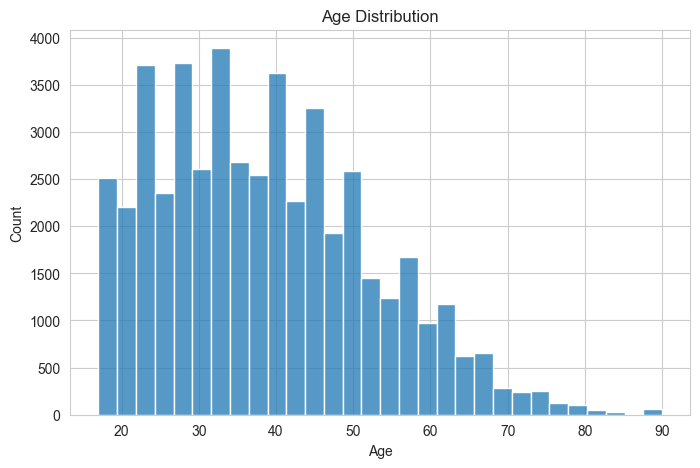

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### 2. Education Number

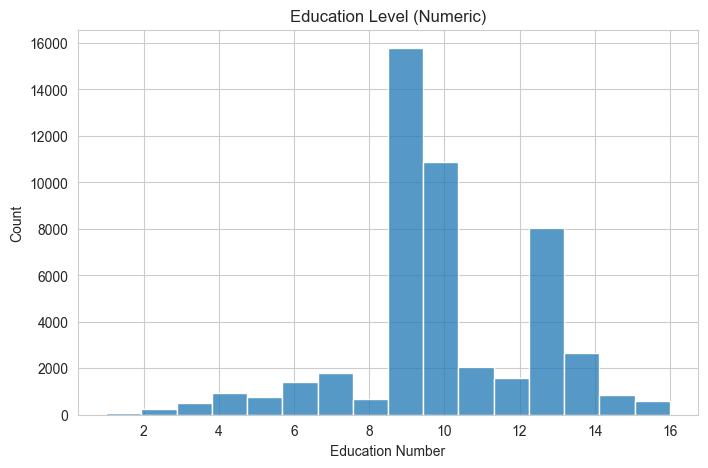

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["education-num"], bins=16)

plt.title("Education Level (Numeric)")
plt.xlabel("Education Number")
plt.ylabel("Count")

plt.show()

### 3. Hours per Week

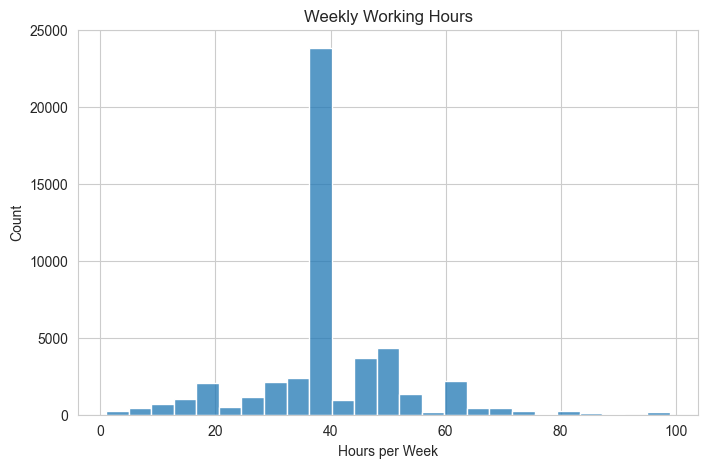

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["hours-per-week"], bins=25)

plt.title("Weekly Working Hours")
plt.xlabel("Hours per Week")
plt.ylabel("Count")

plt.show()

### 4. Capital Gain

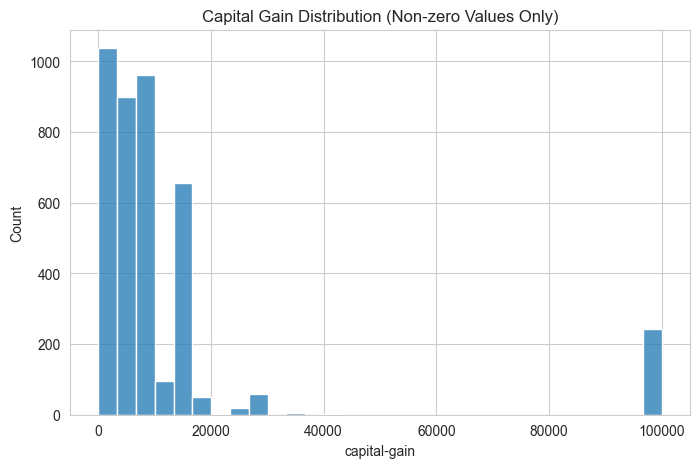

In [15]:
# Most individuals have a capital gain of 0.
# To better visualize the distribution, we plot only the non-zero values.

capital_gain_nonzero = df[df["capital-gain"] > 0]

plt.figure(figsize=(8,5))

sns.histplot(
    capital_gain_nonzero["capital-gain"],
    bins=30
)

plt.title("Capital Gain Distribution (Non-zero Values Only)")

plt.show()

**Observation:**

- The majority of individuals have no capital gain, so only non-zero values are visualized.
- Among individuals with positive capital gains, the distribution is highly right-skewed, with most values clustered at lower gains and a few extremely large values.
- This suggests that `capital-gain` contains significant outliers and may benefit from transformation (e.g., log transformation) or special handling before model training.

### 5. Capital Loss

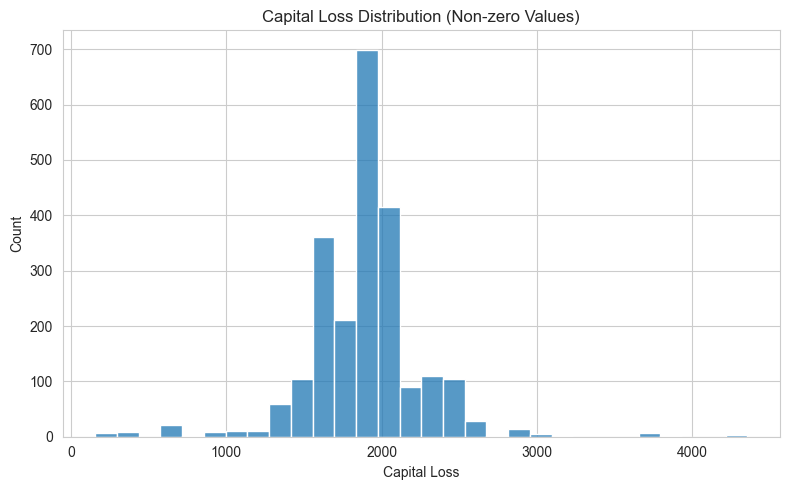

In [16]:
# Most individuals have a capital loss of 0.
# To better visualize the distribution, we plot only the non-zero values.

capital_loss_nonzero = df[df["capital-loss"] > 0]

plt.figure(figsize=(8,5))

sns.histplot(
    data=capital_loss_nonzero,
    x="capital-loss",
    bins=30
)

plt.title("Capital Loss Distribution (Non-zero Values)")
plt.xlabel("Capital Loss")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

### Barplots

### 1. Target Class Distribution

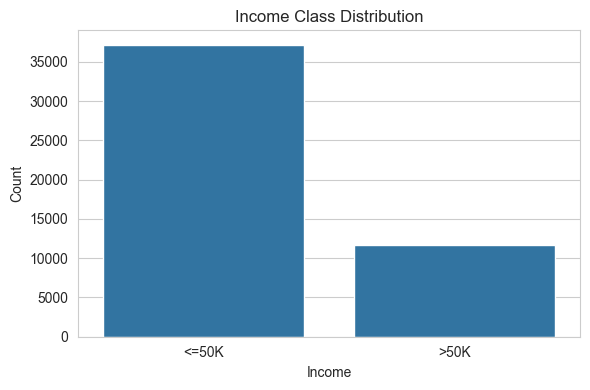

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.xticks([0, 1], ["<=50K", ">50K"])

plt.tight_layout()
plt.show()

### Observation:
Most individuals earn ≤50K annually, indicating that the dataset is moderately imbalanced.

### 2. Education Distribution

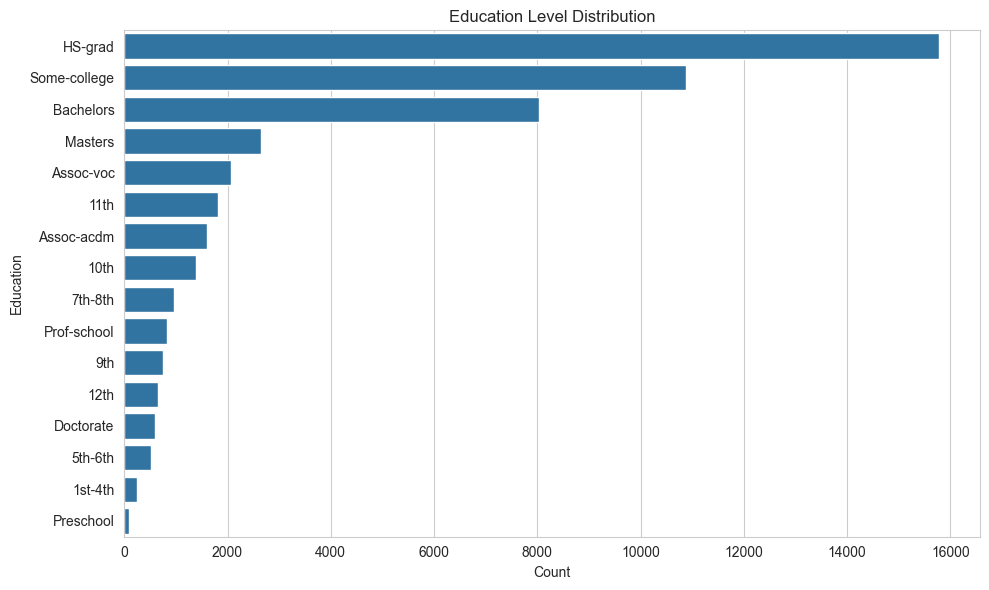

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="education",
    order=df["education"].value_counts().index
)

plt.title("Education Level Distribution")
plt.xlabel("Count")
plt.ylabel("Education")

plt.tight_layout()
plt.show()

### Observation:
High School graduates form the largest group, followed by individuals with some college education.

### 3. Workclass Distribution

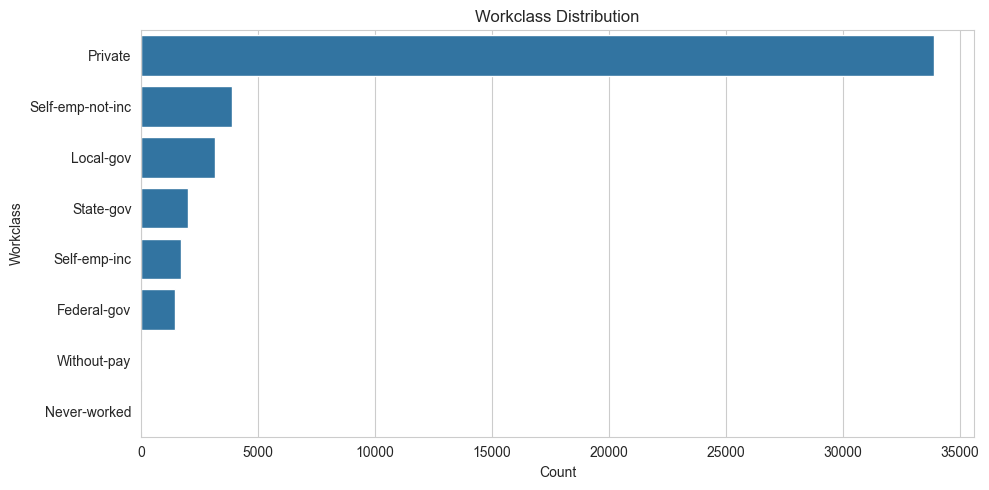

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="workclass",
    order=df["workclass"].value_counts().index
)

plt.title("Workclass Distribution")
plt.xlabel("Count")
plt.ylabel("Workclass")

plt.tight_layout()
plt.show()

### Observation:
Most individuals work in the private sector, with relatively fewer employed in government or self-employment.

### 4. Occupation Distribution

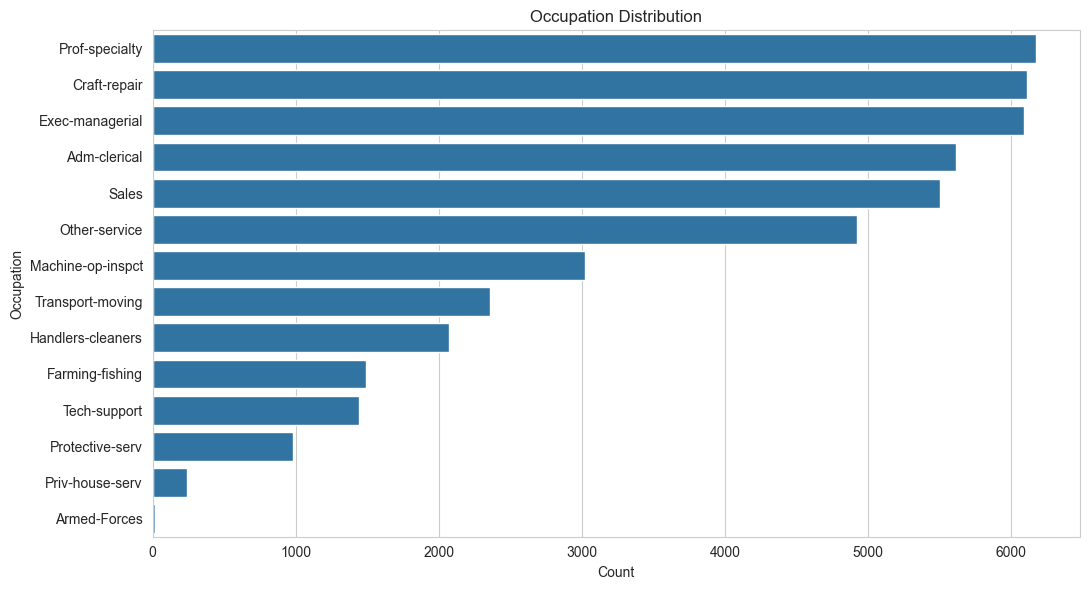

In [20]:
plt.figure(figsize=(11,6))

sns.countplot(
    data=df,
    y="occupation",
    order=df["occupation"].value_counts().index
)

plt.title("Occupation Distribution")
plt.xlabel("Count")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

### Observation:
Professional specialty, craft-repair, and executive-managerial are among the most common occupations.

### Summary Table 

In [21]:
summary_table = pd.DataFrame({
    "Income <=50K": [
        (df["class"] == 0).sum(),
        df["education"].value_counts().iloc[0],
        df["workclass"].value_counts().iloc[0],
        df["sex"].value_counts().iloc[0]
    ],
    "Category": [
        "Income <=50K",
        "Most Common Education",
        "Most Common Workclass",
        "Most Common Gender"
    ],
    "Most Frequent Value": [
        "<=50K",
        df["education"].value_counts().index[0],
        df["workclass"].value_counts().index[0],
        df["sex"].value_counts().index[0]
    ]
})

summary_table

,Income <=50K,Category,Most Frequent Value
0,37155,Income <=50K,<=50K
1,15784,Most Common Education,HS-grad
2,33906,Most Common Workclass,Private
3,32650,Most Common Gender,Male


# Task 3 — Create Reproducible Data Splits

To evaluate a machine learning model fairly, the dataset is divided into separate subsets. The training set is used to learn patterns from the data, while the hold-out test set is kept completely unseen until the final evaluation. This ensures that the reported performance reflects how well the model generalizes to new, unseen data.

### Separate Features and Target

In [22]:
# Features (Independent Variables)
X = df.drop(columns="class")

# Target (Dependent Variable)
y = df["class"]

### Create Appropriate Data Splits

In [23]:
# Step 1: Create the 20% hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# test_size is used to create a test or hold_out split, here 20 % of the data-> 0.20
# we have used stratified sampling and therefore, startify= y for fair evaluation across test and train splits
# we fixed a random state using random_state so that everyone gets the same split everytime thus making this notebook reproducible

# Step 2: Split the remaining 80% into 70% train and 10% development
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)

### Verify Split Sizes

In [24]:
print("Dataset Split Sizes")
print("-" * 30)

print(f"Training Set      : {X_train.shape[0]} samples")
print(f"Development Set   : {X_dev.shape[0]} samples")
print(f"Hold-Out Test Set : {X_test.shape[0]} samples")

Dataset Split Sizes
------------------------------
Training Set      : 34188 samples
Development Set   : 4885 samples
Hold-Out Test Set : 9769 samples


### Verify Stratification

In [25]:
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

dev_distribution = (
    y_dev
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison = pd.DataFrame({
    "Training (%)": train_distribution.round(2),
    "Development (%)": dev_distribution.round(2),
    "Testing (%)": test_distribution.round(2)
})

comparison.index = ["<=50K", ">50K"]

comparison

,Training (%),Development (%),Testing (%)
<=50K,76.07,76.07,76.07
>50K,23.93,23.93,23.93


## Why is a Hold-Out Test Set Necessary?

A hold-out test set provides an unbiased estimate of how well a machine learning model performs on unseen data. It is kept completely separate during model development and is only used after the final model has been selected.

Using the hold-out test set during hyperparameter tuning introduces **test set leakage**, a form of data leakage where information from the test set indirectly influences model selection. This leads to overly optimistic performance estimates and reduces confidence that the model will generalize well to new, unseen data.

# Task 4 — Baseline Models

Before training complex machine learning models, simple baseline models are created to establish a minimum performance benchmark. Any future machine learning model should outperform these baselines to demonstrate that it has learned meaningful patterns from the data.

### Majority Class Predictor

In [26]:
# Create the majority-class baseline model
majority_baseline = DummyClassifier(
    strategy="most_frequent"
)

# Train the model
majority_baseline.fit(X_train, y_train)

# Make predictions on the hold-out test set
y_pred_majority = majority_baseline.predict(X_test)

### Evaluate the Baseline

In [27]:
majority_results = {
    "Accuracy": accuracy_score(y_test, y_pred_majority),
    "Precision": precision_score(y_test, y_pred_majority, zero_division=0),
    "Recall": recall_score(y_test, y_pred_majority, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_majority, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_pred_majority),
    "PR AUC": average_precision_score(y_test, y_pred_majority)
}

# zero division is done so that if anywhere during calculations, there comes a result for 0/0, simply take it as 0

pd.DataFrame(
    majority_results,
    index=["Majority Baseline"]
).round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.0,0.0,0.0,0.5,0.239


### Confusion Matrix

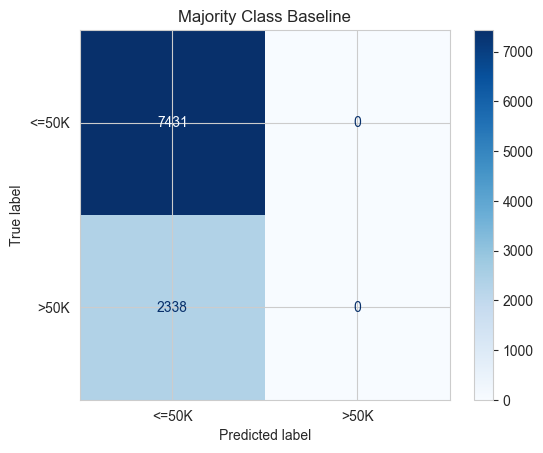

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred_majority
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Blues")

plt.title("Majority Class Baseline")
plt.show()

### Rule-Based Classifier

In [29]:
# Predict >50K if capital-gain > 0

y_pred_rule = (
    X_test["capital-gain"] > 0
).astype(int)

### Evaluate

In [30]:
rule_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rule),
    "Precision": precision_score(y_test, y_pred_rule, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rule, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rule, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_pred_rule),
    "PR AUC": average_precision_score(y_test, y_pred_rule)
}

pd.DataFrame(
    rule_results,
    index=["Rule-Based Baseline"]
).round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Rule-Based Baseline,0.782,0.625,0.225,0.331,0.591,0.326


### Confusion Matrix

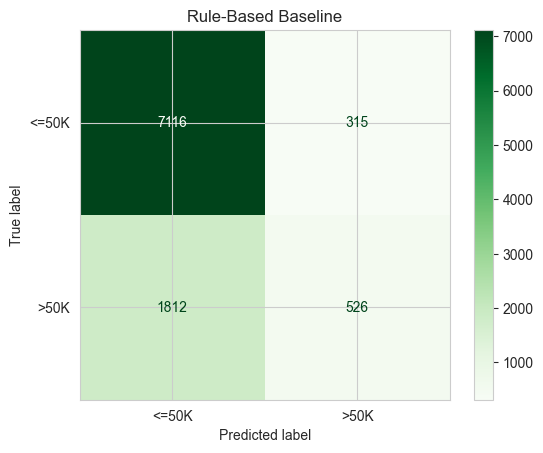

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred_rule
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Greens")

plt.title("Rule-Based Baseline")

plt.show()

### Final Comparison Table

In [32]:
comparison = pd.DataFrame([
    majority_results,
    rule_results
], index=[
    "Majority Baseline",
    "Rule-Based Baseline"
])

comparison.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.761,0.000,0.000,0.000,0.500,0.239
Rule-Based Baseline,0.782,0.625,0.225,0.331,0.591,0.326


### Baseline Model Interpretation

The rule-based classifier outperformed the majority-class baseline across all evaluation metrics. While the majority baseline achieved 76.1% accuracy, it failed to identify any individuals earning more than \$50K, resulting in zero precision, recall, and F1-score for the positive class.

The rule-based classifier, using `capital-gain > 0`, improved the accuracy to 78.2% and achieved a precision of 62.5%, indicating that most of its positive predictions were correct. However, its recall of 22.5% shows that many high-income individuals were still missed. Future machine learning models should aim to improve recall and F1-score while maintaining or improving precision to provide more balanced and useful predictions.

### What's the minimum improvement a real model would need to be considered "useful"?

A useful machine learning model should outperform both baselines across the primary evaluation metrics. In particular, it should achieve a higher F1-score than 0.331 while maintaining strong precision and improving recall, allowing it to identify a larger proportion of high-income individuals without generating excessive false positives.

## Task 5: Initial Error Analysis & Next Steps

### Find False Positives and False Negatives

In [33]:
# Create a copy of the test set for error analysis

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_rule.values

In [34]:
# False Positives
# Predicted >50K but actually <=50K

false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

# False Negatives
# Predicted <=50K but actually >50K

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

In [35]:
print(f"False Positives : {len(false_positives)}")
print(f"False Negatives : {len(false_negatives)}")

False Positives : 315
False Negatives : 1812


In [36]:
# Display 10 False Positives

false_positives.sample(
    n=10,
    random_state=42
)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted
37136,22,Private,190968,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,2407,0,40,United-States,0,1
48796,66,Federal-gov,47358,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,40,United-States,0,1
45354,32,Private,123964,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,4386,0,50,United-States,0,1
17677,54,Private,398212,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,5013,0,40,United-States,0,1
23656,39,Local-gov,116666,HS-grad,9,Never-married,Protective-serv,Own-child,Amer-Indian-Eskimo,Male,4650,0,48,United-States,0,1
31952,39,Private,231141,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,2829,0,40,United-States,0,1
27437,25,Private,40512,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,3674,0,30,United-States,0,1
37691,74,NaN,33114,10th,6,Married-civ-spouse,NaN,Husband,Amer-Indian-Eskimo,Male,1797,0,30,United-States,0,1
14884,30,Private,119562,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,3942,0,40,United-States,0,1
25396,38,Private,51100,Bachelors,13,Divorced,Exec-managerial,Not-in-family,White,Male,3325,0,40,United-States,0,1


In [37]:
# Display 10 False Negatives

false_negatives.sample(
    n=10,
    random_state=42
)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted
10804,38,Private,285890,Bachelors,13,Married-civ-spouse,Tech-support,Husband,Black,Male,0,0,55,United-States,1,0
13191,33,Private,236304,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,60,United-States,1,0
11819,51,Private,169785,Bachelors,13,Married-spouse-absent,Exec-managerial,Not-in-family,White,Female,0,0,60,United-States,1,0
30835,59,Private,70720,Bachelors,13,Divorced,Sales,Not-in-family,White,Male,0,0,55,United-States,1,0
25178,29,Private,137618,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,41,United-States,1,0
35575,42,Private,373469,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,1,0
8035,31,Private,124483,Masters,14,Never-married,Adm-clerical,Not-in-family,Asian-Pac-Islander,Male,0,0,60,India,1,0
2626,53,Private,184176,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,1,0
5796,61,Self-emp-inc,190610,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,1,0
1655,30,Private,156015,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,1,0


## Look for Patterns
### Average numerical values

In [38]:
print("False Positives")
print("-" * 100)
display(false_positives.describe())
print()

print("False Negatives")
print("-" * 100)
display(false_negatives.describe())

False Positives
----------------------------------------------------------------------------------------------------


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,Actual,Predicted
count,315.000000,315.000000,315.000000,315.000000,315.0,315.000000,315.0,315.0
mean,42.133333,191446.904762,9.873016,3403.304762,0.0,40.609524,0.0,1.0
std,15.363784,117516.270530,2.478520,1579.930615,0.0,12.607370,0.0,0.0
min,17.000000,19302.000000,3.000000,114.000000,0.0,1.000000,0.0,1.0
25%,30.500000,108058.000000,9.000000,2354.000000,0.0,40.000000,0.0,1.0
50%,39.000000,177368.000000,9.000000,3325.000000,0.0,40.000000,0.0,1.0
75%,52.500000,240967.000000,12.000000,4386.000000,0.0,45.000000,0.0,1.0
max,90.000000,889965.000000,15.000000,10566.000000,0.0,99.000000,0.0,1.0



False Negatives
----------------------------------------------------------------------------------------------------


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,Actual,Predicted
count,1812.000000,1812.000000,1812.000000,1812.0,1812.000000,1812.000000,1812.0,1812.0
mean,43.575055,191195.949779,11.490066,0.0,216.434879,45.421634,1.0,0.0
std,10.318902,102293.787823,2.371935,0.0,621.569558,10.565770,0.0,0.0
min,22.000000,19914.000000,2.000000,0.0,0.000000,2.000000,1.0,0.0
25%,36.000000,121538.000000,10.000000,0.0,0.000000,40.000000,1.0,0.0
50%,43.000000,179837.500000,12.000000,0.0,0.000000,40.000000,1.0,0.0
75%,50.250000,238168.500000,13.000000,0.0,0.000000,50.000000,1.0,0.0
max,81.000000,953588.000000,16.000000,0.0,3004.000000,99.000000,1.0,0.0


### Most common occupations

In [39]:
print("False Positives")
print("-" * 30)
display(false_positives["occupation"].value_counts().head(10))
print("\n\n")

print("False Negatives")
print("-" * 30)
display(false_negatives["occupation"].value_counts().head(10))

False Positives
------------------------------


occupation
Adm-clerical         48
Craft-repair         40
Exec-managerial      34
Prof-specialty       33
Machine-op-inspct    29
Sales                29
Other-service        28
Transport-moving     17
Farming-fishing      10
Tech-support         10
Name: count, dtype: int64




False Negatives
------------------------------


occupation
Prof-specialty       434
Exec-managerial      421
Sales                240
Craft-repair         227
Adm-clerical         111
Transport-moving      80
Tech-support          71
Machine-op-inspct     52
Protective-serv       48
Other-service         37
Name: count, dtype: int64

### Education

In [40]:
print("False Positives")
print("-" * 30)
display(false_positives["education"].value_counts().head(10))
print("\n\n")

print("False Negatives")
print("-" * 30)
display(false_negatives["education"].value_counts().head(10))

False Positives
------------------------------


education
HS-grad         116
Bachelors        56
Some-college     56
Assoc-voc        19
Masters          15
9th              13
10th             10
Assoc-acdm       10
7th-8th           7
11th              5
Name: count, dtype: int64




False Negatives
------------------------------


education
Bachelors       511
HS-grad         392
Some-college    356
Masters         222
Prof-school      81
Assoc-voc        80
Assoc-acdm       58
Doctorate        55
10th             15
11th             12
Name: count, dtype: int64

### Marital Status

In [41]:
print("False Positives")
print("-" * 30)
display(false_positives["marital-status"].value_counts())
print("\n\n")

print("False Negatives")
print("-" * 30)
display(false_negatives["marital-status"].value_counts())

False Positives
------------------------------


marital-status
Married-civ-spouse       152
Never-married             85
Divorced                  46
Widowed                   21
Separated                  7
Married-spouse-absent      3
Married-AF-spouse          1
Name: count, dtype: int64




False Negatives
------------------------------


marital-status
Married-civ-spouse       1570
Never-married             109
Divorced                   91
Widowed                    14
Separated                  13
Married-spouse-absent      12
Married-AF-spouse           3
Name: count, dtype: int64

## Pattern Summary

- **False Positives (315 cases):** These all have `capital-gain > 0` by construction — the rule flags them purely on this signal. However, their education skews lower (mean `education-num` ≈ 9.87, mostly HS-grad), and occupations lean toward clerical/blue-collar roles (Adm-clerical, Craft-repair, Machine-op-inspct). These appear to be moderate earners with a one-off capital gain (e.g. a stock sale) rather than genuinely high-income individuals.

- **False Negatives (1,812 cases):** All have `capital-gain = 0`, which is exactly why the rule misses them. Education is markedly higher (mean `education-num` ≈ 11.49, dominated by Bachelors/Masters/Prof-school/Doctorate), occupations skew heavily toward Prof-specialty and Exec-managerial (~47% combined), **87% are Married-civ-spouse**, and they work longer hours on average (45.4 vs 40.6 hrs/week for false positives).

- **Overall pattern:** The rule-based classifier is structurally blind to an entire class of high earners — married, highly-educated professionals working long hours who simply don't have capital gains. Because the rule relies on a single financial feature, it ignores education, occupation, marital status, and hours-worked, all of which are strongly correlated with income in this dataset.

## Data & Feature Issues to Fix Tomorrow

1. **Missing categorical values** — `workclass`, `occupation`, and `native-country` contain missing entries (~6% for workclass/occupation) that need explicit imputation (e.g. `"Missing"` category) rather than silent drops.
2. **Capital-gain / capital-loss skew** — Both features are extremely right-skewed with a large mass at zero and a long tail of outliers (up to 99,999). Consider log-transformation or binning (zero vs. non-zero vs. magnitude tiers).
3. **No encoding applied yet** — All categorical features (`workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`) still need one-hot or target encoding before feeding into a real model.
4. **Redundant education features** — `education` (string) and `education-num` (int) encode the same information; keep only `education-num` or verify consistency before dropping one.
5. **High-cardinality `native-country`** — 41 categories with heavy imbalance (United-States = 90% of rows); consider grouping rare countries into an "Other" bucket to avoid sparse encodings.
6. **Marital-status as a strong signal** — Error analysis shows `Married-civ-spouse` is present in 87% of false negatives, suggesting this feature (possibly combined with `relationship`) may be one of the most predictive features tomorrow — worth checking for multicollinearity with `relationship` before modeling.

## Primary Metric for the Week

Based on today's baseline results, **F1-score** (or **PR AUC**, given the ~24% class imbalance) will be the primary metric to optimize for the rest of the week. The majority-class baseline scored an F1 of 0.0, and the rule-based baseline improved this only to **F1 = 0.331** (Precision = 0.625, Recall = 0.225, PR AUC = 0.326). This confirms the business objective from Task 1: precision matters more than recall, since false positives waste marketing outreach — but the rule-based baseline's recall of 22.5% is too low to be practically useful, missing the majority of genuine high-income individuals entirely. A model built tomorrow should be considered a meaningful improvement if it can raise F1 well above 0.331 (e.g. toward 0.55–0.65) while keeping precision at or above the 0.625 baseline, since that would mean catching substantially more true positives without sacrificing the low-false-positive-rate the business objective requires.